# EDA — Customer Churn

Análisis exploratorio del dataset histórico de Customer Churn, según los requisitos de la Entrega 1: dimensiones, tipos, valores faltantes, distribución del target, variables relevantes y problemas de calidad de datos.

Este notebook es solo para exploración: el entrenamiento y la inferencia se ejecutan desde código Python en `src/`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RAIZ_PROYECTO = Path.cwd().parent
sys.path.append(str(RAIZ_PROYECTO))

from src.data.carga_datos import cargar_datos_historicos, COLUMNA_ID, COLUMNA_TARGET

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 4)

df = cargar_datos_historicos()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6684-LWVH,Male,0,No,No,4,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,27.56,107.47,No
1,7027-JIFO,Male,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,30.52,1020.47,No
2,5981-VOQO,Female,0,No,No,45,Yes,Yes,DSL,No,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),66.87,2686.35,No
3,7266-HYDM,Male,0,Yes,No,31,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),86.95,2536.96,Yes
4,2821-JDLS,Female,0,Yes,No,5,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,30.18,139.12,No


## 1. Dimensiones y tipos de datos

In [2]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.dtypes

Filas: 7043, Columnas: 21


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Valores faltantes

In [4]:
faltantes = df.isnull().sum()
porcentaje_faltantes = (faltantes / len(df) * 100).round(2)
pd.DataFrame({"faltantes": faltantes, "% faltantes": porcentaje_faltantes}).query("faltantes > 0")

,faltantes,% faltantes
TotalCharges,26,0.37


In [5]:
filas_con_faltantes = df[df["TotalCharges"].isnull()]
filas_con_faltantes["tenure"].value_counts()

tenure
0    26
Name: count, dtype: int64

**Interpretación:** las 26 filas con `TotalCharges` faltante tienen `tenure = 0`, es decir, clientes nuevos que todavía no acumularon facturación. No es un error de carga sino un patrón consistente: en el pipeline de preprocesamiento corresponde imputar estos casos con `0`.

## 3. Distribución de la variable objetivo (`Churn`)

In [6]:
conteo_churn = df[COLUMNA_TARGET].value_counts()
proporcion_churn = df[COLUMNA_TARGET].value_counts(normalize=True).round(3)
pd.DataFrame({"clientes": conteo_churn, "proporcion": proporcion_churn})

,clientes,proporcion
Churn,,
No,5186,0.736
Yes,1857,0.264


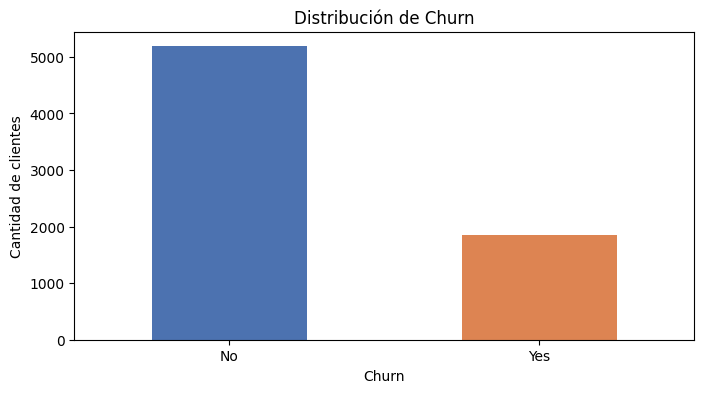

In [7]:
conteo_churn.plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

**Interpretación:** el target está desbalanceado (~26,5% `Yes`). Esto respalda lo indicado en la consigna: accuracy no alcanza como única métrica; conviene priorizar Recall/F1/ROC-AUC al comparar modelos y al elegir el threshold, dado que un falso negativo (cliente que iba a abandonar y se clasifica como estable) tiene un costo de negocio directo.

## 4. Variables numéricas relevantes

In [8]:
columnas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
df[columnas_numericas].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7017.000000
mean,35.168394,68.168503,2312.077586
std,18.901478,24.980659,1573.967858
min,0.000000,18.000000,0.000000
25%,20.000000,55.360000,986.630000
50%,35.000000,73.910000,2013.200000
75%,51.000000,88.000000,3452.850000
max,72.000000,114.410000,7761.340000


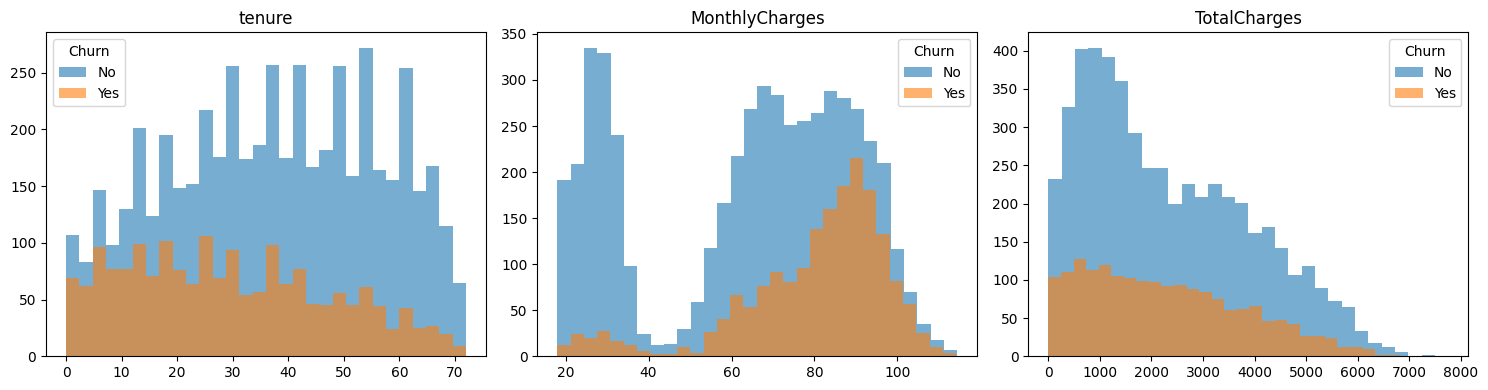

In [9]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
for eje, columna in zip(ejes, columnas_numericas):
    for valor_churn, grupo in df.groupby(COLUMNA_TARGET):
        eje.hist(grupo[columna].dropna(), bins=30, alpha=0.6, label=valor_churn)
    eje.set_title(columna)
    eje.legend(title="Churn")
plt.tight_layout()
plt.show()

**Interpretación:** los clientes con menor antigüedad (`tenure` bajo) y cargos mensuales (`MonthlyCharges`) más altos muestran mayor proporción de `Churn = Yes`.

**Chequeo de consistencia (extra):** `TotalCharges` debería aproximarse a `tenure * MonthlyCharges`. Verificarlo ayuda a confirmar que no hay corrupción en los datos cargados.

In [10]:
estimado = df["tenure"] * df["MonthlyCharges"]
diferencia_relativa = ((df["TotalCharges"] - estimado).abs() / estimado.replace(0, pd.NA)).dropna()
diferencia_relativa.describe()

count     7013.000000
unique    7013.000000
top          0.025127
freq         1.000000
dtype: float64

**Interpretación:** la diferencia relativa es baja en promedio, lo que es consistente con un cargo mensual que varía levemente en el tiempo (altas/bajas de servicios) y no evidencia problemas de calidad en estas tres columnas.

## 5. Variables categóricas relevantes

In [11]:
def tasa_churn_por_categoria(columna: str) -> pd.Series:
    return (
        df.groupby(columna)[COLUMNA_TARGET]
        .apply(lambda serie: (serie == "Yes").mean())
        .sort_values(ascending=False)
    )

tasa_churn_por_categoria("Contract")

Contract
Month-to-month    0.387300
One year          0.149736
Two year          0.089744
Name: Churn, dtype: float64

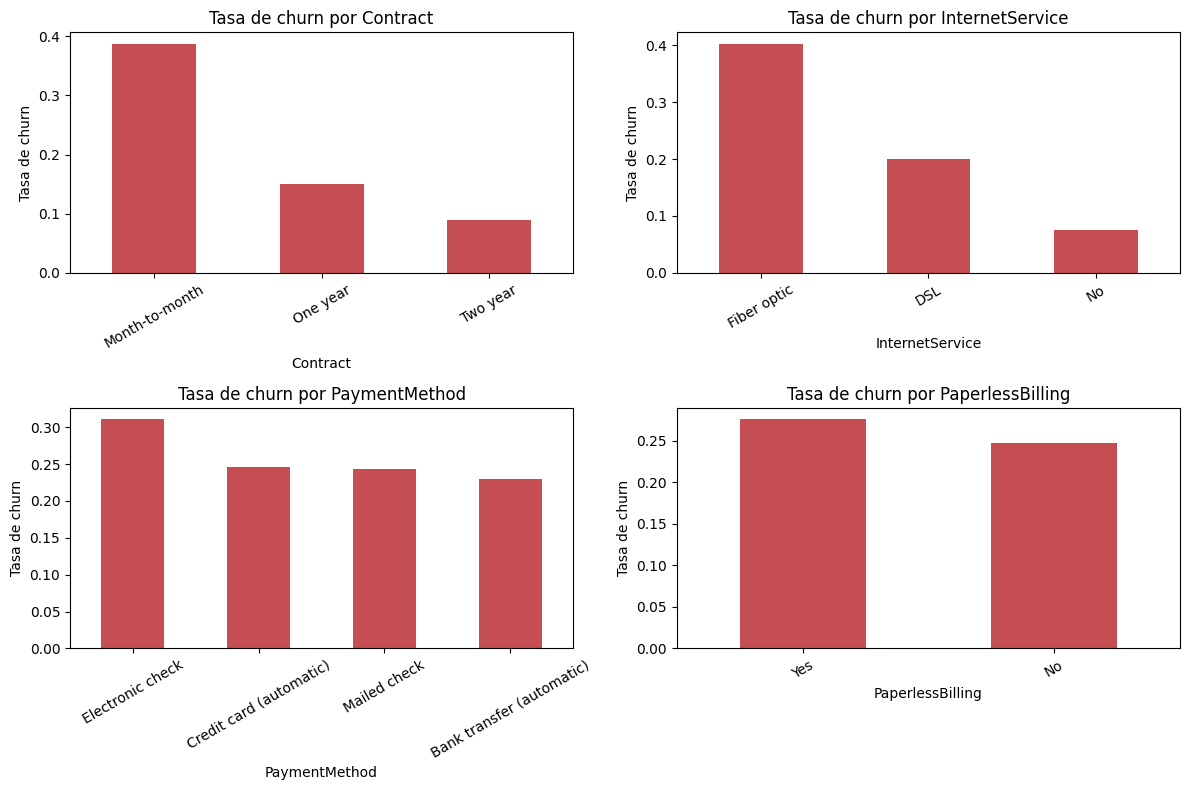

In [12]:
columnas_categoricas_clave = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]
fig, ejes = plt.subplots(2, 2, figsize=(12, 8))
for eje, columna in zip(ejes.ravel(), columnas_categoricas_clave):
    tasa_churn_por_categoria(columna).plot(kind="bar", ax=eje, color="#C44E52")
    eje.set_title(f"Tasa de churn por {columna}")
    eje.set_ylabel("Tasa de churn")
    eje.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Interpretación:** los contratos `Month-to-month`, el servicio `Fiber optic`, el pago por `Electronic check` y la facturación `Paperless` muestran tasas de churn notablemente más altas. Son variables con señal fuerte para el modelo.

## 6. Identificador de cliente

In [13]:
print("customerID es único:", df[COLUMNA_ID].is_unique)
print("Filas completamente duplicadas:", df.duplicated().sum())

customerID es único: True
Filas completamente duplicadas: 0


`customerID` es único y no hay filas duplicadas. Tal como indica el diccionario de datos, no se utiliza como predictor.

## 7. Consistencia de dominios categóricos

In [14]:
columnas_categoricas = df.select_dtypes(include="object").columns.drop([COLUMNA_ID, COLUMNA_TARGET])
for columna in columnas_categoricas:
    print(f"{columna}: {sorted(df[columna].unique())}")

gender: ['Female', 'Male']
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'No phone service', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'No internet service', 'Yes']
OnlineBackup: ['No', 'No internet service', 'Yes']
DeviceProtection: ['No', 'No internet service', 'Yes']
TechSupport: ['No', 'No internet service', 'Yes']
StreamingTV: ['No', 'No internet service', 'Yes']
StreamingMovies: ['No', 'No internet service', 'Yes']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


Los dominios observados coinciden con `metadata/data_dictionary.csv`: no aparecen categorías inesperadas, variantes de mayúsculas/minúsculas ni valores nulos disfrazados como texto.

## 8. Resumen de calidad de datos y conclusiones para el pipeline

- Dataset de 7.043 filas y 21 columnas, sin filas duplicadas.
- `customerID` es único y se excluye como predictor.
- Único faltante real: `TotalCharges` (26 casos, 0,37%), que coincide exactamente con `tenure = 0` → imputar con `0` en el pipeline de preprocesamiento.
- Target desbalanceado (~26,5% `Yes`) → no usar accuracy como única métrica; priorizar Recall/F1/ROC-AUC y evaluar el threshold en función del costo de negocio de un falso negativo.
- Dominios categóricos limpios y consistentes con el diccionario de datos.
- Variables con señal aparente de churn: `tenure`, `Contract`, `InternetService`, `PaymentMethod`, `MonthlyCharges`, `PaperlessBilling`.
- Próximo paso: partición train/test reproducible y `Pipeline` de preprocesamiento (`SimpleImputer` + `OneHotEncoder` + `StandardScaler` cuando corresponda) antes de comparar baseline, modelo lineal y modelo de árbol en MLflow.